# How untying helps — three steps

**Exploratory** (subproject `tied_untied/`). Why does untying the decoder from the encoder help a sparse ReLU autoencoder? A case study at `n=5, m=2` (five features in a 2-D bottleneck), built as a three-step ladder on the reconstruction operator `A[i,k]` = *feature i's contribution to feature k's readout* (before the final ReLU):

1. **Transpose → pseudoinverse.** The pseudoinverse is a better inverse than the transpose — it minimizes `‖A − I‖` (drives the operator toward the identity). The right direction, though after bias+ReLU it isn't *guaranteed* to lower the loss.
2. **Beat the pseudoinverse: unbounded negative.** `‖A − I‖` penalizes negative crosstalk, but the ReLU clips negative interference into inactive targets to zero. The trained decoder can therefore use more negative off-diagonals, though these can hurt when features co-fire.
3. **Asymmetric negative.** Break the operator's symmetry — large-negative one way, ~0 the other. Clipping protects inactive targets from negative interference, and the ~0 reverse direction helps preserve one reconstruction when two features **co-fire**.

In [1]:
from pathlib import Path as _ReleasePath
import os as _release_os
import sys as _release_sys
_release_root = next(p for p in [_ReleasePath.cwd(), *_ReleasePath.cwd().parents]
                     if (p / 'lib/core.py').is_file())
_release_os.chdir(_release_root)
_release_sys.path.insert(0, str(_release_root / 'lib'))

%matplotlib inline
import torch, numpy as np, matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True); torch.manual_seed(0)
n, m, S = 5, 2, 0.9
def data(B): return (torch.rand(B,n)>S).float()*torch.rand(B,n)
def ev(fn,B=300000):
    x=data(B)
    with torch.no_grad(): return float(((fn(x)-x)**2).mean())
def ev_kactive(fn,k,B=200000):     # loss on patterns with EXACTLY k active features
    idx=torch.argsort(torch.rand(B,n),dim=1)[:,:k]; mask=torch.zeros(B,n); mask.scatter_(1,idx,1.0)
    X=mask*torch.rand(B,n)
    with torch.no_grad(): return float(((fn(X)-X)**2).mean())
def tied(W,b): return lambda x: torch.relu((x@W.T)@W+b)
def untied(We,D,b): return lambda x: torch.relu((x@We.T)@D+b)

# converge tied, then warm-start UNTIED at the tied solution
W=torch.zeros(m,n).normal_(0,.4).requires_grad_(True); bT=torch.zeros(n,requires_grad=True)
o=torch.optim.Adam([W,bT],lr=3e-3)
for _ in range(30000):
    x=data(4096); (tied(W,bT)(x)-x).pow(2).mean().backward(); o.step(); o.zero_grad()
W=W.detach(); bT=bT.detach()
We=W.clone().requires_grad_(True); D=W.clone().requires_grad_(True); bU=bT.clone().requires_grad_(True)
o=torch.optim.Adam([We,D,bU],lr=1e-3)
for _ in range(30000):
    x=data(4096); (untied(We,D,bU)(x)-x).pow(2).mean().backward(); o.step(); o.zero_grad()
We=We.detach(); D=D.detach(); bU=bU.detach()
print(f"tied loss   = {ev(tied(W,bT)):.5f}")
print(f"untied loss = {ev(untied(We,D,bU)):.5f}   (+{(ev(tied(W,bT))-ev(untied(We,D,bU)))/ev(tied(W,bT))*100:.0f}%)")

tied loss   = 0.00523
untied loss = 0.00313   (+42%)


## Part 1 — Transpose vs pseudoinverse: the right direction

Fix a superposed encoder (a regular pentagon — five unit feature-directions 72° apart in 2-D). Decoding a feature means reading the code `z` along some direction; the resulting reconstruction operator is `A = (read)·(write)`. Two linear choices:
- **transpose:** read along the write direction ⇒ `A = EᵀE` (the Gram matrix).
- **pseudoinverse:** read along the *dual* direction ⇒ `A = E⁺E`, which is the closest any linear decoder gets to the identity.

The pseudoinverse minimizes `‖A − I‖` — a genuinely better inverse.

In [2]:
k=np.arange(5); E=np.vstack([np.cos(2*np.pi*k/5), np.sin(2*np.pi*k/5)])   # pentagon, unit columns
A_T=E.T@E; A_P=np.linalg.pinv(E)@E
fro=lambda M: float(np.linalg.norm(M-np.eye(n)))
print(f"||E^T E - I||  (transpose)     = {fro(A_T):.3f}")
print(f"||E^+ E - I||  (pseudoinverse) = {fro(A_P):.3f}   <- smaller: pinv drives the operator closer to I")
print("\n=> the pseudoinverse is the better INVERSE (it decorrelates: reads away from interferers).")
print("   Whether that lowers the ReLU loss is Part 2 -- and the ReLU wants to go FURTHER than pinv does.")

||E^T E - I||  (transpose)     = 2.739
||E^+ E - I||  (pseudoinverse) = 1.732   <- smaller: pinv drives the operator closer to I

=> the pseudoinverse is the better INVERSE (it decorrelates: reads away from interferers).
   Whether that lowers the ReLU loss is Part 2 -- and the ReLU wants to go FURTHER than pinv does.


**Caveat (sets up Part 2).** `‖A − I‖` treats every off-diagonal error the same, positive or negative. But with a ReLU + negative bias, a *negative* off-diagonal is harmless — when the interfering feature fires, it only pushes the (inactive) target further below zero, where the ReLU clips it to 0 anyway. So minimizing `‖A − I‖` (what the pseudoinverse does) is leaving free lunch on the table.

## Part 2 — Beat the pseudoinverse: unbounded negative crosstalk

Negative crosstalk into an inactive target is clipped to zero. In this example, the trained decoder drives off-diagonals **far more negative** than the pseudoinverse would — the pseudoinverse keeps them modest (it's minimizing symmetric squared error), the trained decoder does not. This interference can still hurt when the target feature is active. Compare the two operators, and where the win lands: on **single-active** patterns (killing the interference leak).

In [3]:
A_unt=(We.T@D).numpy()             # trained untied operator (before ReLU)
off=lambda A: A[~np.eye(n,dtype=bool)]
print(f"pseudoinverse operator (P): off-diagonals in [{off(A_P).min():.2f}, {off(A_P).max():.2f}]  (modest, symmetric)")
print(f"trained untied operator   : off-diagonals in [{off(A_unt).min():.1f}, {off(A_unt).max():.2f}]  (huge NEGATIVE, ReLU-clipped)")
print("\nwhere untying's edge lands (loss by # co-firing features):")
tf=tied(W,bT); uf=untied(We,D,bU)
print(f"  {'#active':>8}{'tied':>10}{'untied':>10}{'gain':>9}")
for kk in [1,2,3]:
    lt=ev_kactive(tf,kk); lu=ev_kactive(uf,kk); print(f"  {kk:>8}{lt:>10.5f}{lu:>10.5f}{(lt-lu)/lt*100:>+8.0f}%")

pseudoinverse operator (P): off-diagonals in [-0.32, 0.12]  (modest, symmetric)
trained untied operator   : off-diagonals in [-143.5, 0.08]  (huge NEGATIVE, ReLU-clipped)

where untying's edge lands (loss by # co-firing features):
   #active      tied    untied     gain
         1   0.00357   0.00007     +98%
         2   0.04544   0.03260     +28%
         3   0.08895   0.08440      +5%


The single-active gain is enormous (~+98%): one feature firing used to leak a *positive* bump onto its pentagon neighbours (the dead zone the bias couldn't clean); the unbounded-negative crosstalk sends that bump below zero instead, and the ReLU deletes it. But driving crosstalk hugely negative in **both** directions would wreck reconstruction when two features co-fire — which motivates Part 3.

## Part 3 — Asymmetric negative crosstalk: the co-firing payoff

The final move is to make the crosstalk **asymmetric**: large-negative one direction (`A[i,k]`), ~0 the other (`A[k,i]`). Two ingredients explain the benefit here: **clipping** prevents negative interference into an inactive target from producing a negative output, and **co-firing** makes the direction matter. When features *i* and *k* are both on, a sufficiently strong symmetric negative pair can drive *both* readouts below zero, whereas the asymmetric version can keep one alive.

In [4]:
# Part 3a -- the analytic 2-feature toy
b=np.array([-0.05,-0.05])
rec=lambda A,x: np.maximum(x@A+b,0)
A_sym=np.array([[1.,-5.],[-5.,1.]])     # symmetric large-negative
A_asy=np.array([[1.,-5.],[ 0.,1.]])     # asymmetric: -5 one way, 0 the other
print("2-feature toy  (reconstruct k = ReLU(sum_i x_i A[i,k] + b)):")
for lbl,x in [("only f0",[0.5,0]),("only f1",[0,0.5]),("BOTH co-fire",[0.5,0.5])]:
    x=np.array(x); print(f"  {lbl:14} true={x}   symmetric-> {rec(A_sym,x)}   asymmetric-> {rec(A_asy,x)}")
print("  => co-firing: symmetric destroys BOTH; asymmetric preserves one.")

2-feature toy  (reconstruct k = ReLU(sum_i x_i A[i,k] + b)):
  only f0        true=[0.5 0. ]   symmetric-> [0.45 0.  ]   asymmetric-> [0.45 0.  ]
  only f1        true=[0.  0.5]   symmetric-> [0.   0.45]   asymmetric-> [0.   0.45]
  BOTH co-fire   true=[0.5 0.5]   symmetric-> [0. 0.]   asymmetric-> [0.45 0.  ]
  => co-firing: symmetric destroys BOTH; asymmetric preserves one.


trained untied operator asymmetry:  ||K||/||A|| = 0.71   (0 = symmetric)


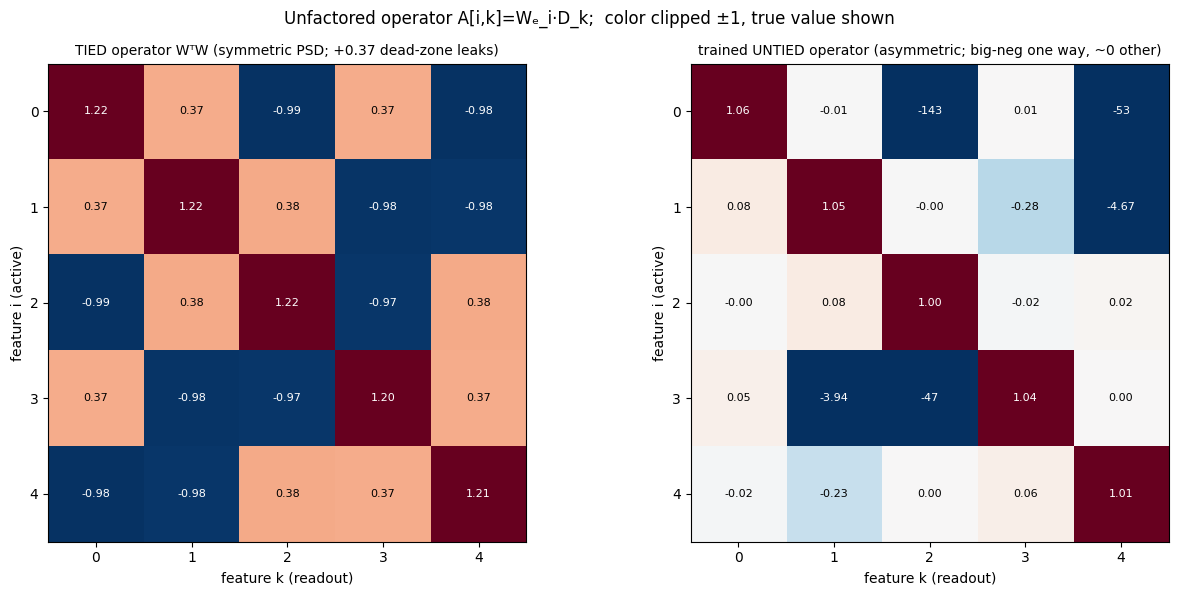

In [5]:
A_tied=(W.T@W).numpy(); A_unt=(We.T@D).numpy(); K=(A_unt-A_unt.T)/2
print(f"trained untied operator asymmetry:  ||K||/||A|| = {np.linalg.norm(K)/np.linalg.norm(A_unt):.2f}   (0 = symmetric)")
def show_op(ax,A,title):
    ax.imshow(np.clip(A,-1,1),cmap='RdBu_r',vmin=-1,vmax=1)
    for i in range(n):
        for j in range(n):
            v=A[i,j]; ax.text(j,i,(f'{v:.2f}' if abs(v)<10 else f'{v:.0f}'),ha='center',va='center',fontsize=8,
                              color='white' if abs(np.clip(v,-1,1))>0.55 else 'black')
    ax.set_title(title,fontsize=10); ax.set_xlabel('feature k (readout)'); ax.set_ylabel('feature i (active)')
fig,axs=plt.subplots(1,2,figsize=(13,6))
show_op(axs[0],A_tied,'TIED operator WᵀW (symmetric PSD; +0.37 dead-zone leaks)')
show_op(axs[1],A_unt,'trained UNTIED operator (asymmetric; big-neg one way, ~0 other)')
plt.suptitle('Unfactored operator A[i,k]=Wₑ_i·D_k;  color clipped ±1, true value shown'); plt.tight_layout(); plt.show()

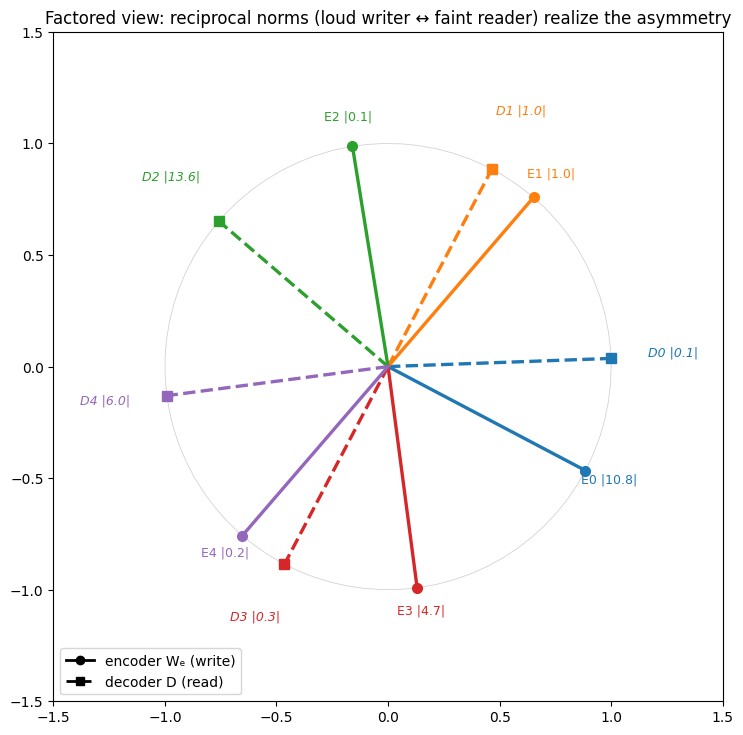

In [6]:
# Part 3 -- the factored geometry: encoder (write) vs decoder (read) directions
fig,ax=plt.subplots(figsize=(7.5,7.5)); col=plt.cm.tab10(np.arange(n))
for i in range(n):
    wu=(We[:,i]/We[:,i].norm()).numpy(); du=(D[:,i]/D[:,i].norm()).numpy()
    ax.plot([0,wu[0]],[0,wu[1]],'-',color=col[i],lw=2.4); ax.plot(*wu,'o',color=col[i],ms=7)
    ax.plot([0,du[0]],[0,du[1]],'--',color=col[i],lw=2.4); ax.plot(*du,'s',color=col[i],ms=7)
    ax.text(wu[0]*1.12,wu[1]*1.12,f'E{i} |{We[:,i].norm():.1f}|',color=col[i],fontsize=9,ha='center')
    ax.text(du[0]*1.28,du[1]*1.28,f'D{i} |{D[:,i].norm():.1f}|',color=col[i],fontsize=9,ha='center',style='italic')
t=np.linspace(0,2*np.pi,80); ax.plot(np.cos(t),np.sin(t),color='lightgray',lw=.6,zorder=0)
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_aspect('equal')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='k',lw=2,marker='o',label='encoder Wₑ (write)'),
                   Line2D([0],[0],color='k',lw=2,ls='--',marker='s',label='decoder D (read)')],loc='lower left')
ax.set_title('Factored view: reciprocal norms (loud writer ↔ faint reader) realize the asymmetry'); plt.tight_layout(); plt.show()

## Synthesis — the three-step ladder

Reading the reconstruction operator `A` as *"how much feature i leaks into feature k's readout"*, untying climbs three rungs:

1. **Pseudoinverse over transpose** — the least-squares-best inverse pushes `A` toward `I` (`‖A−I‖: 2.739 → 1.732`). The right direction, but it penalizes negative crosstalk even when clipping makes it harmless for an inactive target.
2. **Unbounded negative** — the trained decoder is optimized for reconstruction loss, not `‖A−I‖`, and uses large negative off-diagonals. These are clipped for inactive targets, nearly eliminating single-active interference here (~+98% on 1-active patterns), but they can suppress active targets.
3. **Asymmetric** — strong symmetric negative interference can destroy both features when they co-fire. The trained untied solution breaks symmetry (large one way, ~0 the other), preserving one reconstruction in these pairs (+28% on 2-active patterns here). Tying forces a symmetric positive-semidefinite operator `WᵀW`, so it cannot realize this asymmetry. Its entries are not generally bounded by `[−1,1]`; that bound requires encoder columns with norms at most one.